In [7]:
import os
import ot 
import torch
import scipy
import scipy.sparse as sp
import anndata as ad
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'src').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))
import model.uot_alignment as al
import utils.compute_lr as clr 

In [ ]:
adata = sc.read_h5ad("data/mouse_brain/processed/mouse_embedding.h5ad")
adata

AnnData object with n_obs × n_vars = 152586 × 19547
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'region', 'coor_x', 'coor_y', 'raw_x', 'raw_y', 'distance', 'area', 'Astrocyte', 'Bergmann', 'Choroid', 'Endothelial_mural', 'Endothelial_stalk', 'Ependymal', 'Fibroblast', 'Golgi', 'Granule', 'MLI1', 'MLI2', 'Macrophage', 'Microglia', 'ODC', 'OPC', 'PLI', 'Purkinje', 'UBC', 'cluster', 'annotation', 'sample', 'n_genes', '_scvi_batch', '_scvi_labels', 'leiden_scVI'
    var: 'n_counts'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'annotation_colors', 'leiden_scVI', 'leiden_scVI_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_scanVI', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [8]:
adata.obs_names_make_unique()
adata.raw = adata  

lr_pairs = pd.read_csv("data/lrpairs/mouse/LR_pairs.csv")
print(lr_pairs.iloc[:1, 2:4])
ligand_list = lr_pairs['ligand'].unique()
receptor_list = lr_pairs['receptor'].unique()

gene_idx = pd.Index(adata.var_names.astype(str))
ligand   = gene_idx.intersection(pd.Index(ligand_list))
receptor = gene_idx.intersection(pd.Index(receptor_list))
ligand_df   = pd.DataFrame(ligand.sort_values(), columns=["ligand"])
receptor_df = pd.DataFrame(receptor.sort_values(), columns=["receptor"])
print("ligand gene num: ", len(ligand))
print("receptor gene num: ", len(receptor))
feat = adata.var_names.astype(str).values

X = adata.X
X = X.toarray() if sp.issparse(X) else X

expr = pd.DataFrame(X, index=adata.obs_names, columns=feat)

expr_L = expr.loc[:, expr.columns.intersection(ligand)]
expr_R = expr.loc[:, expr.columns.intersection(receptor)]

print(expr_L.iloc[:2, :2])
print(expr_R.iloc[:2, :2])

  ligand   receptor
0  Tgfb1  TGFbR1_R2
ligand gene num:  378
receptor gene num:  295
         Col9a1  Sema4c
268_226     0.0     0.0
217_190     0.0     0.0
         Npbwr1  Oprk1
268_226     0.0    0.0
217_190     0.0    0.0


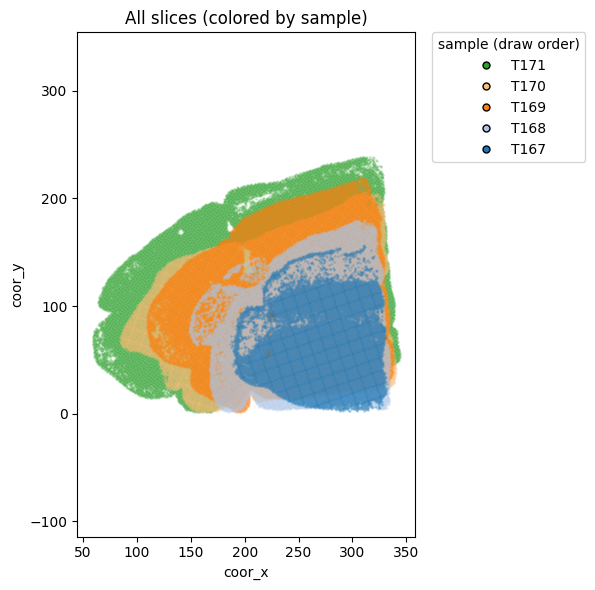

In [9]:
obs = adata.obs.copy()
x_all = obs["coor_x"].to_numpy()
y_all = obs["coor_y"].to_numpy()
samples = obs["sample"].astype("category")
cats = list(samples.cat.categories)
plot_order = list(reversed(cats))
cmap = plt.get_cmap("tab20")
color_map = {cat: cmap(i % 20) for i, cat in enumerate(cats)}

plt.figure(figsize=(6,6), dpi=100)

for cat in plot_order:
    mask = (samples.to_numpy() == cat)
    plt.scatter(
        x_all[mask],
        y_all[mask],
        s=3,
        c=[color_map[cat]],
        linewidths=0,
        alpha=0.3,
        label=str(cat),         
    )

plt.xlabel("coor_x")
plt.ylabel("coor_y")
plt.title("All slices (colored by sample)")

handles = [
    plt.Line2D(
        [0],[0],
        marker='o',
        color='none',
        markerfacecolor=color_map[cat],
        markersize=5,
        label=str(cat)
    )
    for cat in plot_order
]
plt.legend(
    handles=handles,
    title="sample (draw order)",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0.
)

plt.axis("equal")
plt.tight_layout()
plt.show()

In [42]:
import importlib
importlib.reload(al)
ref_sample = "T171"

all_samples = list(pd.Categorical(obs["sample"]).categories)

print("All samples:", all_samples)
print("Reference sample:", ref_sample)

XY_all = obs[["coor_x", "coor_y"]].to_numpy(dtype=np.float32)
xy_min = np.nanmin(XY_all, axis=0)  # (2,)
xy_max = np.nanmax(XY_all, axis=0)  # (2,)
xy_scale = (xy_max - xy_min).astype(np.float32)
xy_scale[xy_scale == 0] = 1.0

def xy_norm(X):
    X = X.astype(np.float32, copy=False)
    return (X - xy_min) / xy_scale

def xy_denorm(Xn):
    Xn = Xn.astype(np.float32, copy=False)
    return Xn * xy_scale + xy_min

print("Normalize params:")
print("  xy_min  =", xy_min)
print("  xy_max  =", xy_max)

for k in ["cx_aligned", "cy_aligned", "cx_aligned_norm", "cy_aligned_norm"]:
    if k not in adata.obs.columns:
        adata.obs[k] = np.nan

mask_ref = (obs["sample"] == ref_sample)

X_ref_orig = obs.loc[mask_ref, ["coor_x", "coor_y"]].to_numpy(dtype=np.float32)
X_ref_norm = xy_norm(X_ref_orig)

ann_ref = obs.loc[mask_ref, "annotation"].to_numpy()

adata.obs.loc[mask_ref, "cx_aligned"] = X_ref_orig[:, 0]
adata.obs.loc[mask_ref, "cy_aligned"] = X_ref_orig[:, 1]
adata.obs.loc[mask_ref, "cx_aligned_norm"] = X_ref_norm[:, 0]
adata.obs.loc[mask_ref, "cy_aligned_norm"] = X_ref_norm[:, 1]

for s in all_samples:
    if s == ref_sample:
        continue

    print(f"\n=== Registering {s} → {ref_sample} (on normalized coords) ===")

    mask_s = (obs["sample"] == s)

    X_src_orig = obs.loc[mask_s, ["coor_x", "coor_y"]].to_numpy(dtype=np.float32)
    X_src_norm = xy_norm(X_src_orig)

    ann_src = obs.loc[mask_s, "annotation"].to_numpy()

    X_src_aligned, info = al.register_slice_to_ref_robust(
        X_src_norm, X_ref_norm,
        ann_src=ann_src,
        ann_ref=ann_ref,
        n_sub=5000,
        n_starts=6,
        reg=None,
        reg_m=1.0,
        icp_iter=50,
        icp_sub=20000,
        use_class_after=10,
        verbose=True,
    )

    print("final theta:", info["refine"]["theta"])
    print("final t:", info["refine"]["t"])

    X_src_warped_orig = xy_denorm(X_src_aligned)

    adata.obs.loc[mask_s, "cx_aligned_norm"] = X_src_aligned[:, 0]
    adata.obs.loc[mask_s, "cy_aligned_norm"] = X_src_aligned[:, 1]
    adata.obs.loc[mask_s, "cx_aligned"] = X_src_warped_orig[:, 0]
    adata.obs.loc[mask_s, "cy_aligned"] = X_src_warped_orig[:, 1]

print("\nDone.")
print("  aligned (orig): adata.obs['cx_aligned'], ['cy_aligned']")
print("  aligned (norm): adata.obs['cx_aligned_norm'], ['cy_aligned_norm']")

All samples: ['T167', 'T168', 'T169', 'T170', 'T171']
Reference sample: T171
Normalize params:
  xy_min  = [58.818462   1.3394516]
  xy_max  = [344.2527 238.6984]

=== Registering T167 → T171 (on normalized coords) ===


UOT init:   0%|          | 0/18 [00:28<?, ?it/s, best=0.09786, reg=0.0128, score=0.1014, th=0.000324, trial=18]


[UOT init] BEST score=0.097860 reg=0.0127974 theta=0.0032 t=[-0.18750587870579571, 0.20165146282645247]


ICP refine: 100%|██████████| 50/50 [00:02<00:00, 20.76it/s, cls=1, med=0.01389, p90=0.04881, th=-0.0205, tx=-0.192, ty=0.193]


final theta: -0.020460366813467072
final t: [-0.19221619801034193, 0.1933002780526769]

=== Registering T168 → T171 (on normalized coords) ===


...

final theta: 0.03683957148338095
final t: [-0.0847594103538571, 0.0435985926761851]

=== Registering T170 → T171 (on normalized coords) ===


UOT init:   0%|          | 0/18 [00:27<?, ?it/s, best=0.02063, reg=0.0163, score=0.02267, th=-0.0241, trial=18]


[UOT init] BEST score=0.020634 reg=0.0163069 theta=-0.0232 t=[-0.0397850526194895, 0.07792538493893036]


ICP refine: 100%|██████████| 50/50 [00:02<00:00, 17.05it/s, cls=1, med=0.001905, p90=0.01864, th=-0.0389, tx=-0.00621, ty=0.0361]

final theta: -0.0389261222378674
final t: [-0.0062085352942798915, 0.03612176365449176]

Done.
  aligned (orig): adata.obs['cx_aligned'], ['cy_aligned']
  aligned (norm): adata.obs['cx_aligned_norm'], ['cy_aligned_norm']


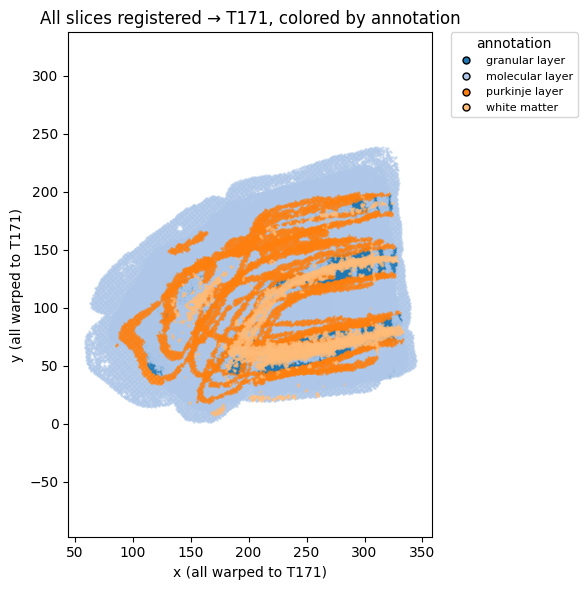

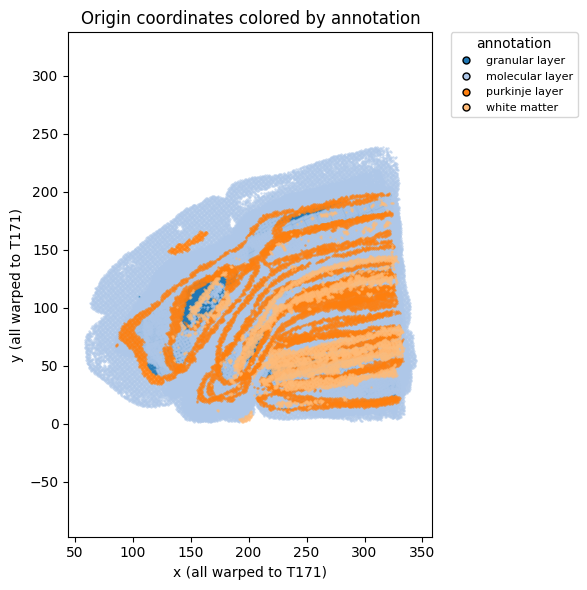

before bbox: (np.float64(255.9723619413405), np.float64(203.83306703191863))
after  bbox: (np.float64(257.1983642578125), np.float64(208.67071628570557))


In [43]:
df_all = pd.DataFrame({
    "x_warp": adata.obs["cx_aligned"].to_numpy(),
    "y_warp": adata.obs["cy_aligned"].to_numpy(),
    "annotation": adata.obs["annotation"].to_numpy(),
    "sample": adata.obs["sample"].to_numpy()
})

df_all = df_all[~np.isnan(df_all["x_warp"]) & ~np.isnan(df_all["y_warp"])]
ann_cats = pd.Categorical(df_all["annotation"]).categories.tolist()
cmap = plt.get_cmap("tab20")
ann_color_map = {ann: cmap(i % 20) for i, ann in enumerate(ann_cats)}

plt.figure(figsize=(6,6), dpi=100)
for ann in ann_cats:
    m = (df_all["annotation"] == ann)
    plt.scatter(
        df_all.loc[m, "x_warp"],
        df_all.loc[m, "y_warp"],
        s=3,
        c=[ann_color_map[ann]],
        alpha=0.6,
        linewidths=0,
        label=str(ann)
    )

# plt.gca().invert_yaxis()

plt.axis("equal")
plt.xlabel("x (all warped to T171)")
plt.ylabel("y (all warped to T171)")
plt.title("All slices registered → T171, colored by annotation")

# 
handles = [
    plt.Line2D(
        [0],[0],
        marker='o',
        color='none',
        markerfacecolor=ann_color_map[ann],
        markersize=5,
        label=str(ann)
    )
    for ann in ann_cats
]
plt.legend(
    handles=handles,
    title="annotation",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0.,
    fontsize=8
)

plt.tight_layout()
plt.show()



df_all = pd.DataFrame({
    "x_warp": adata.obs["coor_x"].to_numpy(),
    "y_warp": adata.obs["coor_y"].to_numpy(),
    "annotation": adata.obs["annotation"].to_numpy(),
    "sample": adata.obs["sample"].to_numpy()
})

df_all = df_all[~np.isnan(df_all["x_warp"]) & ~np.isnan(df_all["y_warp"])]
ann_cats = pd.Categorical(df_all["annotation"]).categories.tolist()
cmap = plt.get_cmap("tab20")
ann_color_map = {ann: cmap(i % 20) for i, ann in enumerate(ann_cats)}

plt.figure(figsize=(6,6), dpi=100)
for ann in ann_cats:
    m = (df_all["annotation"] == ann)
    plt.scatter(
        df_all.loc[m, "x_warp"],
        df_all.loc[m, "y_warp"],
        s=3,
        c=[ann_color_map[ann]],
        alpha=0.6,
        linewidths=0,
        label=str(ann)
    )

# plt.gca().invert_yaxis()

plt.axis("equal")
plt.xlabel("x (all warped to T171)")
plt.ylabel("y (all warped to T171)")
plt.title("Origin coordinates colored by annotation")

# 
handles = [
    plt.Line2D(
        [0],[0],
        marker='o',
        color='none',
        markerfacecolor=ann_color_map[ann],
        markersize=5,
        label=str(ann)
    )
    for ann in ann_cats
]
plt.legend(
    handles=handles,
    title="annotation",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0.,
    fontsize=8
)

plt.tight_layout()
plt.show()

def bbox_size(X):
    # X shape (N,2)
    w = X[:,0].max() - X[:,0].min()
    h = X[:,1].max() - X[:,1].min()
    return w, h

#  sample s:
mask_s = (adata.obs["sample"] == "T170")
X_before = obs.loc[mask_s, ["coor_x","coor_y"]].to_numpy()
X_after  = adata.obs.loc[mask_s, ["cx_aligned","cy_aligned"]].to_numpy()

print("before bbox:", bbox_size(X_before))
print("after  bbox:", bbox_size(X_after))


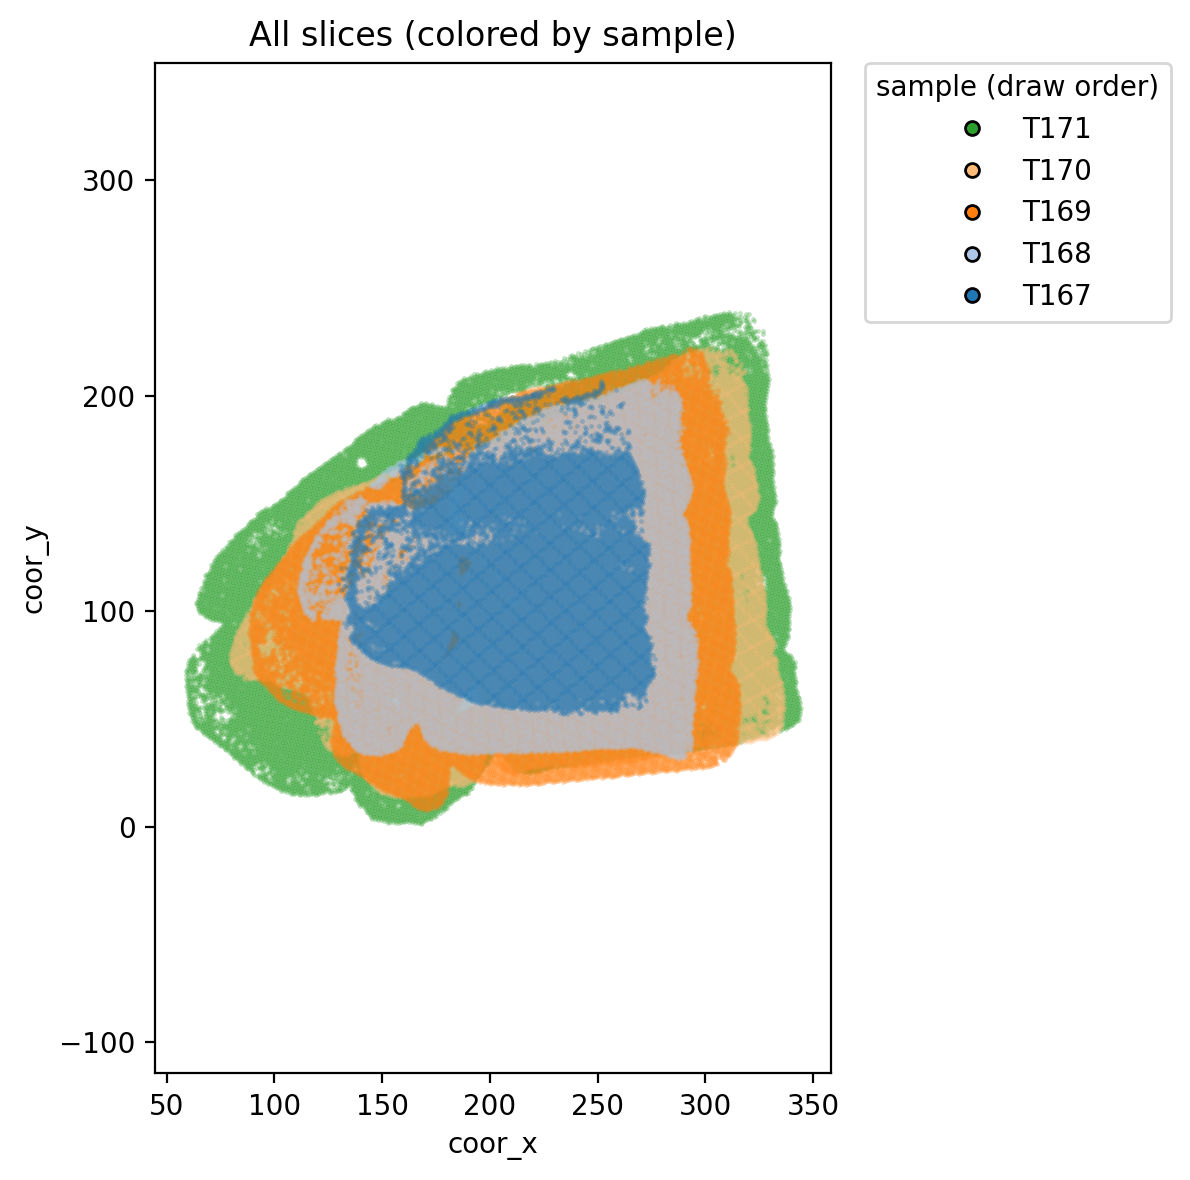

In [44]:
obs = adata.obs.copy()
x_all = obs["cx_aligned"].to_numpy()
y_all = obs["cy_aligned"].to_numpy()
samples = obs["sample"].astype("category")
cats = list(samples.cat.categories)
plot_order = list(reversed(cats))
cmap = plt.get_cmap("tab20")
color_map = {cat: cmap(i % 20) for i, cat in enumerate(cats)}

plt.figure(figsize=(6,6), dpi=200)

for cat in plot_order:
    mask = (samples.to_numpy() == cat)
    plt.scatter(
        x_all[mask],
        y_all[mask],
        s=3,
        c=[color_map[cat]],
        linewidths=0,
        alpha=0.3,
        label=str(cat),         
    )

plt.xlabel("coor_x")
plt.ylabel("coor_y")
plt.title("All slices (colored by sample)")

handles = [
    plt.Line2D(
        [0],[0],
        marker='o',
        color='none',
        markerfacecolor=color_map[cat],
        markersize=5,
        label=str(cat)
    )
    for cat in plot_order
]
plt.legend(
    handles=handles,
    title="sample (draw order)",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0.
)

plt.axis("equal")
plt.tight_layout()
plt.show()

In [48]:
clr.compute_lr_potential_per_sample(
    adata, lr_pairs,
    sample_key="sample",
    coords_key="spatial",
    layer="counts",   #  'counts' , None
    k=6, use_cpm=False,
    hill=True, pair_chunk=64, verbose=True
)

[LR] 有效 LR 配对 644 条（在 var_names 中均存在）
  - sample 'T167': 14205 cells
  - sample 'T168': 23487 cells
  - sample 'T169': 33921 cells
  - sample 'T170': 34874 cells
  - sample 'T171': 46099 cells
[LR] 完成：写入 adata.obs['LR_potential'] 与 'LR_potential_z'


AnnData object with n_obs × n_vars = 152586 × 19547
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'region', 'coor_x', 'coor_y', 'raw_x', 'raw_y', 'distance', 'area', 'Astrocyte', 'Bergmann', 'Choroid', 'Endothelial_mural', 'Endothelial_stalk', 'Ependymal', 'Fibroblast', 'Golgi', 'Granule', 'MLI1', 'MLI2', 'Macrophage', 'Microglia', 'ODC', 'OPC', 'PLI', 'Purkinje', 'UBC', 'cluster', 'annotation', 'sample', 'n_genes', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 'cx_aligned', 'cy_aligned', 'cx_aligned_norm', 'cy_aligned_norm', 'LR_potential', 'LR_potential_z', 'LR_potential_z_smooth', 'LR_potential_z_smooth_w'
    var: 'n_counts'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'annotation_colors', 'leiden_scVI', 'leiden_scVI_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_scanVI', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

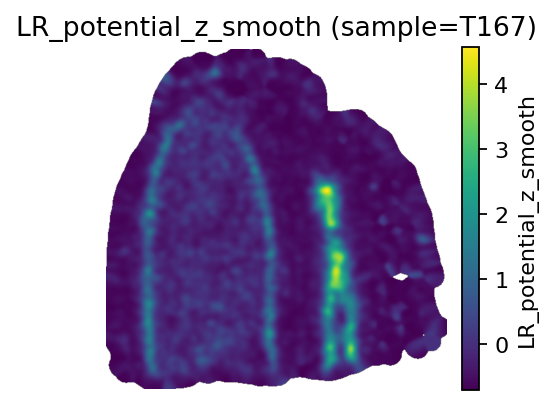

[done] sample=T167: wrote 14205/14205 values to obs['LR_potential_z_smooth']


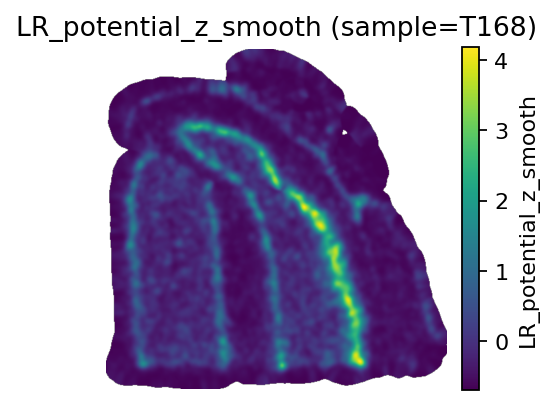

[done] sample=T168: wrote 23487/23487 values to obs['LR_potential_z_smooth']


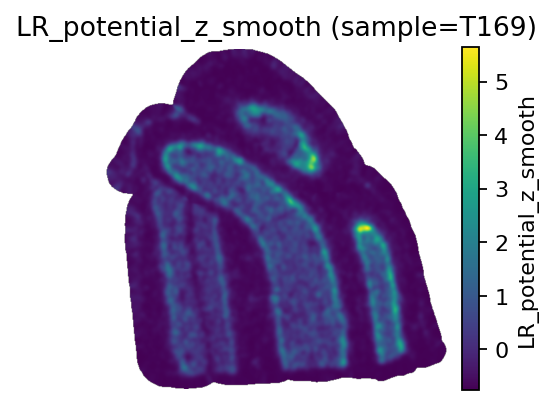

[done] sample=T169: wrote 33921/33921 values to obs['LR_potential_z_smooth']


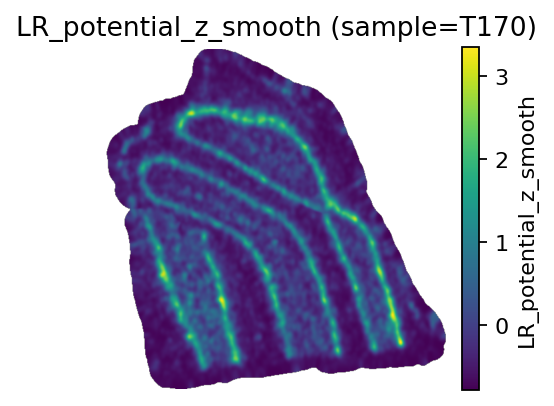

[done] sample=T170: wrote 34874/34874 values to obs['LR_potential_z_smooth']


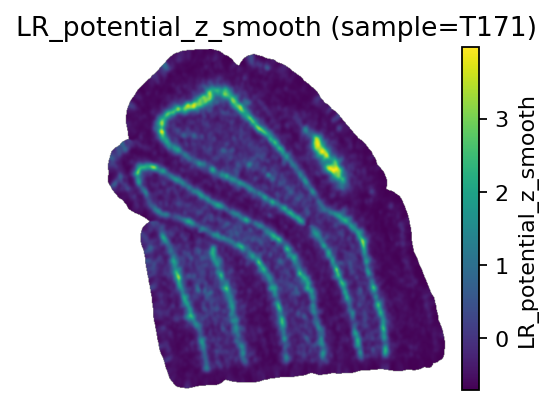

[done] sample=T171: wrote 46099/46099 values to obs['LR_potential_z_smooth']


In [49]:
adata = clr.render_lr_potential_smooth(
    adata,
    key="LR_potential_z",           #  "LR_potential"
    sample_key="sample",
    coords_key=None,                #  obsm
    obs_xy=("cx_aligned", "cy_aligned"),    #  obs coordinatescolumn
    bins=512,
    sigma_mode="knn",
    k=6,
)

In [50]:
adata.write_h5ad("data/mouse_brain/processed/mouse.h5ad")